# Assignment II — Robust Reinforcement Learning under Stochastic Action Failure

**Group Contribution Declaration**

| Name | Roll No. | Contribution (%) |
|---|---|---|
| Aishwarya G M | 2025AA05151 | 100 |
| Amit Pandey | 2025AA05184 | 100 |
| Aditya  | 2025AB05080 | 100 |
| Ranjan Basak | 2025AA05709 | 100 |
| Murlidhar Pandey | 2025AA05182 | 100 |

We have implemented:

- **(a)** A `gym.Wrapper` modifying `LunarLander-v3` according to assignment instructions.
- **(b)** A Deep Q-Network (DQN) agent, trained on both the original and the modified environment.
- **(c)** A Double DQN (DDQN) agent, trained on both the original and the modified environment.
- **(d)** Comparison plots for the four trained agents (DQN/DDQN × original/modified).
- **(e)** Discussion and answering the assignment's analysis questions.

In [1]:
from datetime import datetime      
print("Execution timestamp :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
import socket
print("Machine hostname    :", socket.gethostname())   
print("-" * 55)

Execution timestamp : 2026-08-06 23:22:47
Machine hostname    : 2025aa05151
-------------------------------------------------------


## 0. Setup

In [69]:
!pip install "gymnasium[box2d]" box2d -q

In [70]:
import random
from collections import deque, namedtuple
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim

from gymnasium.wrappers import RecordVideo
from IPython.display import Video

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# same seed for reproducibilty
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

Using device: cuda


## (a) Modified Environment: Implementation and Verification

We have modified `LunarLander-v3` environment as per following steps:
- agent randomly performs action=0 15%, if selected action is not 0.
- Calculate the reward based on given formula: `R = R_base − 0.3·1[a ∈ {1,2,3}] + bonus`
- bonus=50 for safe landing, 0 otherwise
- Landing is safe only when `v_horizontal < 0.1, v_vertical < 0.1, orientation_angle < 0.1` and left and right leg are in landing area.

In [71]:
class StochasticLunarLander(gym.Wrapper):

    def __init__(self, env, failure_prob=0.15, fuel_penalty=0.3, landing_bonus=50.0):
        super().__init__(env)

        self.failure_prob = failure_prob
        self.fuel_penalty = fuel_penalty
        self.landing_bonus = landing_bonus

        self.stats = {"thruster_attempts": 0,"misfires": 0,"landing_bonus_awarded": 0,}
        self._last_decomposition = None

    @staticmethod
    def is_safe_landing(obs, terminated, truncated):
        # returns true if episode ends in safe landing, else false
        if not terminated or truncated:
            return False
        left_leg, right_leg = obs[6], obs[7]
        vx, vy, theta = obs[2], obs[3], obs[4]
        return (
            left_leg == 1 and right_leg == 1
            and abs(vx) < 0.10 and abs(vy) < 0.10 and abs(theta) < 0.10
        )

    def step(self, action):
        a = int(action)
        if a == 0:
            a_exec = 0
        else:
            self.stats["thruster_attempts"] += 1
            # Use Gymnasium's seeded RNG
            r = self.np_random.random()
            if r < self.failure_prob:
                a_exec = 0
                self.stats["misfires"] += 1
            else:
                a_exec = a

        obs, r_base, terminated, truncated, info = self.env.step(a_exec)
        fuel_penalty = self.fuel_penalty if a in (1, 2, 3) else 0.0
        reward = r_base - fuel_penalty
        bonus = 0.0

        if self.is_safe_landing(obs, terminated, truncated):
            bonus = self.landing_bonus
            self.stats["landing_bonus_awarded"] += 1

        reward += bonus
        self._last_decomposition = {
            "a": a,
            "a_exec": a_exec,
            "r_base": r_base,
            "fuel_penalty_applied": fuel_penalty,
            "bonus_applied": bonus,
        }

        return obs, reward, terminated, truncated, info
    def reset(self, **kwargs):
        return self.env.reset(**kwargs)


### Verification
We are running a random policy and logging, and verifying if behaviour is as expected.

In [72]:
def run_random_policy_verification(num_episodes=500, seed=SEED):
    env = StochasticLunarLander(gym.make("LunarLander-v3"))

    env.action_space.seed(seed)
    rows = []
    for ep in range(num_episodes):
        obs, info = env.reset(seed=seed + ep)
        terminated = truncated = False
        while not (terminated or truncated):
            a = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(a)
            d = env._last_decomposition
            rows.append({
                "episode": ep,
                "a": d["a"],
                "a_exec": d["a_exec"],
                "was_thruster": d["a"] in (1, 2, 3),
                "misfired": d["a"] in (1, 2, 3) and d["a_exec"] == 0,
                "r_base": d["r_base"],
                "fuel_penalty_applied": d["fuel_penalty_applied"],
                "bonus_applied": d["bonus_applied"],
                "reward": reward,
                "terminated": terminated,
                "truncated": truncated,
            })
    env.close()
    return pd.DataFrame(rows), env.stats

log_df, stats = run_random_policy_verification(num_episodes=500)
print(stats)
log_df.head()


{'thruster_attempts': 32841, 'misfires': 4834, 'landing_bonus_awarded': 14}


,episode,a,a_exec,was_thruster,misfired,r_base,fuel_penalty_applied,bonus_applied,reward,terminated,truncated
0,0,0,0,False,False,1.144980,0.0,0.0,1.144980,False,False
1,0,3,3,True,False,0.187972,0.3,0.0,-0.112028,False,False
2,0,2,2,True,False,-5.533589,0.3,0.0,-5.833589,False,False
3,0,1,1,True,False,1.815577,0.3,0.0,1.515577,False,False
4,0,1,0,True,True,1.168616,0.3,0.0,0.868616,False,False


##### Check 1 — approximately 15% of thruster actions are replaced by Do Nothing

Thruster attempts logged: 32841
Misfires (replaced by Do Nothing): 4834
Misfire rate: 0.1472  (expected ~0.15)
95% CI: [0.1434, 0.1510]


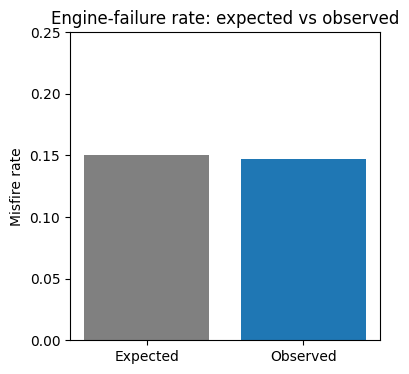

In [73]:
thruster_df = log_df[log_df["was_thruster"]]
misfire_rate = thruster_df["misfired"].mean()
print(f"Thruster attempts logged: {len(thruster_df)}")
print(f"Misfires (replaced by Do Nothing): {thruster_df['misfired'].sum()}")
print(f"Misfire rate: {misfire_rate:.4f}  (expected ~0.15)")

n = len(thruster_df)
se = np.sqrt(misfire_rate * (1 - misfire_rate) / n)
print(f"95% CI: [{misfire_rate - 1.96*se:.4f}, {misfire_rate + 1.96*se:.4f}]")

plt.figure(figsize=(4, 4))
plt.bar(["Expected", "Observed"], [0.15, misfire_rate], color=["gray", "tab:blue"])
plt.ylabel("Misfire rate")
plt.title("Engine-failure rate: expected vs observed")
plt.ylim(0, 0.25)
plt.show()


##### Check 2 — fuel penalty is charged on every attempted thruster action, fired or misfired

In [74]:
penalty_by_outcome = thruster_df.groupby("misfired")["fuel_penalty_applied"].agg(["mean", "min", "max", "count"])
penalty_by_outcome.index = penalty_by_outcome.index.map({True: "misfired -> a_exec=0", False: "fired normally"})
print(penalty_by_outcome)

assert np.allclose(thruster_df["fuel_penalty_applied"], 0.3), "Fuel penalty was not exactly 0.3 for some thruster attempt"
do_nothing_df = log_df[~log_df["was_thruster"]]
assert np.allclose(do_nothing_df["fuel_penalty_applied"], 0.0), "A Do-Nothing action was incorrectly penalised"
print("\nConfirmed: every thruster attempt (fired or misfired) is penalised -0.3; Do-Nothing actions are not penalised.")


                      mean  min  max  count
misfired                                   
fired normally         0.3  0.3  0.3  28007
misfired -> a_exec=0   0.3  0.3  0.3   4834

Confirmed: every thruster attempt (fired or misfired) is penalised -0.3; Do-Nothing actions are not penalised.


#### Check 3 — the +50 landing bonus is awarded only when the safe-landing criteria hold

In [75]:
bonus_rows = log_df[log_df["bonus_applied"] > 0]
print(f"Total bonus-awarding steps: {len(bonus_rows)}")
print(f"Total times bonus awarded: {stats['landing_bonus_awarded']}")

# every bonus step must be a terminated (not truncated) step
assert bonus_rows["terminated"].all() and (~bonus_rows["truncated"]).all()
print("Confirmed: bonus only ever appears on terminated, non-truncated steps.")

Total bonus-awarding steps: 14
Total times bonus awarded: 14
Confirmed: bonus only ever appears on terminated, non-truncated steps.


Above checks ensure the StochasticLunarLander modified environment behaves exactly as we intend for it to, and doesnt do any other state / reward changes.

## DQN and DDQN Agents

Both agents share the same network architecture, optimizer, replay buffer, ε-greedy schedule, seed and hyperparameters.
- `train_dqn(..., double_dqn=False)` trains a vanilla DQN;
- `train_dqn(..., double_dqn=True)` trains a DDQN by changing only the target-Q computation.

Here we decouple action selection from action evaluation using the online network.

In [76]:
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    # Fixed-capacity FIFO experience replay buffer with uniform random sampling.
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    # Simple MLP, it has 1 input layer (8-dim LunarLander state),1 hidden layer, 1 output layer (4 action)
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, action_dim),
        )

    def forward(self, x):
        return self.net(x)


In [77]:
# Hyperparameters shared identically across DQN/DDQN and original/modified environment runs.
HYPERPARAMS = dict(
    num_episodes=1000, # total episodes to run
    max_steps=1000, # Max steps in an episode
    gamma=0.99,
    lr=5e-4,
    batch_size=64,
    buffer_capacity=100000,
    min_buffer_size=1000, # Initial exploration steps
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.995,
    target_update_every=1000,
    hidden_dim=128, # hidden layer size of MLP in DDQN
)


In [78]:
from gymnasium.wrappers import RecordVideo
from IPython.display import Video
import shutil
import os

def record_policy_video(agent, env_fn, output_name):
    video_dir = "video_tmp"
    if os.path.exists(video_dir):
        shutil.rmtree(video_dir)

    env = env_fn(render_mode="rgb_array")
    env = RecordVideo(env, video_folder=video_dir, episode_trigger=lambda episode: True,)
    state, _ = env.reset(seed=SEED)
    done = False

    while not done:
        if agent is None:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                action = agent(state_t).argmax().item()
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
    env.close()

    videos = sorted(f for f in os.listdir(video_dir)if f.endswith(".mp4"))
    shutil.copy(os.path.join(video_dir, videos[-1]), output_name)
    print(f"Saved {output_name}")
    return Video(output_name, embed=True)

### Fixed validation state set
Here we have:
- sampled once from the original environment under a random policy
- reused it to evaluate *every* agent throughout training

Therefore the reported Q-values are comparable across runs.

In [79]:
def build_validation_states(num_states=200, seed=SEED):
    env = gym.make("LunarLander-v3")
    env.action_space.seed(seed)
    states = []
    obs, info = env.reset(seed=seed)
    while len(states) < num_states:
        a = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(a)
        states.append(np.array(obs, dtype=np.float32))
        if terminated or truncated:
            obs, info = env.reset(seed=seed + len(states))
    env.close()
    return np.stack(states)

VALIDATION_STATES = build_validation_states()
print("Validation set shape:", VALIDATION_STATES.shape)


Validation set shape: (200, 8)


In [80]:
def train_dqn(env_fn, seed, double_dqn, hyperparams=HYPERPARAMS, validation_states=VALIDATION_STATES, label=""):
    # Function trains DQN and DDQN agent
    # env_fn is callable returns environment instance
    # double_dqn = True for DDQN, false for DQN
    # Return a dictionary of per-episode metrics

    set_seed(seed)
    env = env_fn()
    env.action_space.seed(seed)

    if hasattr(env, "observation_space"):
        env.observation_space.seed(seed)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    q_net = QNetwork(state_dim, action_dim, hyperparams["hidden_dim"]).to(device)
    target_net = QNetwork(state_dim, action_dim, hyperparams["hidden_dim"]).to(device)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=hyperparams["lr"])
    buffer = ReplayBuffer(hyperparams["buffer_capacity"])
    val_states_t = torch.tensor(validation_states, dtype=torch.float32, device=device)

    epsilon = hyperparams["eps_start"]
    history = {
        "episode_reward": [], "avg_q_value": [], "landing_success": [],
        "landing_success_ma100": [], "thruster_activations": [],
    }
    gradient_steps = 0
    for episode in range(hyperparams["num_episodes"]):
        obs, info = env.reset(seed=seed + episode)
        state = np.array(obs, dtype=np.float32)
        ep_reward, thruster_count, steps = 0.0, 0, 0
        terminated = truncated = False

        while not (terminated or truncated) and steps < hyperparams["max_steps"]:
            steps += 1
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    state_t = torch.from_numpy(state).unsqueeze(0).to(device)
                    action = int(q_net(state_t).argmax(dim=1).item())

            if action in (1, 2, 3):
                thruster_count += 1

            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = np.array(next_obs, dtype=np.float32)
            done = terminated or truncated

            buffer.push(state, action, reward, next_state, float(done))
            state = next_state
            ep_reward += reward

            if len(buffer) >= hyperparams["min_buffer_size"]:
                batch = buffer.sample(hyperparams["batch_size"])
                states_b = torch.tensor(np.array(batch.state), dtype=torch.float32, device=device)
                actions_b = torch.tensor(batch.action, dtype=torch.int64, device=device).unsqueeze(1)
                rewards_b = torch.tensor(batch.reward, dtype=torch.float32, device=device).unsqueeze(1)
                next_states_b = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
                dones_b = torch.tensor(batch.done, dtype=torch.float32, device=device).unsqueeze(1)

                q_values = q_net(states_b).gather(1, actions_b)

                with torch.no_grad():
                    if double_dqn: # DDQN
                        next_actions = q_net(next_states_b).argmax(dim=1, keepdim=True)
                        next_q = target_net(next_states_b).gather(1, next_actions)
                    else: # DQN
                        next_q = target_net(next_states_b).max(dim=1, keepdim=True)[0]
                    target_q = rewards_b + hyperparams["gamma"] * next_q * (1 - dones_b)

                loss = nn.functional.smooth_l1_loss(q_values, target_q)
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(q_net.parameters(), 10)
                optimizer.step()
                gradient_steps += 1

        epsilon = max(hyperparams["eps_end"], epsilon * hyperparams["eps_decay"])
        if gradient_steps % hyperparams["target_update_every"] == 0:
            target_net.load_state_dict(q_net.state_dict())

        success = int(StochasticLunarLander.is_safe_landing(state, terminated, truncated))

        with torch.no_grad():
            avg_q = q_net(val_states_t).max(dim=1)[0].mean().item()

        history["episode_reward"].append(ep_reward)
        history["avg_q_value"].append(avg_q)
        history["landing_success"].append(success)
        history["thruster_activations"].append(thruster_count)
        window = history["landing_success"][-100:]
        history["landing_success_ma100"].append(sum(window) / len(window))

        if (episode + 1) % 50 == 0:
            print(f"[{label}] ep {episode:4d}  reward {ep_reward:8.2f}  "
                  f"avgQ {avg_q:7.2f}  success_ma100 {history['landing_success_ma100'][-1]:.2f}  eps {epsilon:.3f}")

    env.close()
    return history, q_net


### Train the four agents

We train all four combination here. All four runs use the identical hyperparameters and the identical seed.

In [81]:
# Function to return original environment instance
def make_original(render_mode=None):
    return gym.make("LunarLander-v3", render_mode=render_mode)


# Function to return modified environment instance
def make_modified(render_mode=None):
    return StochasticLunarLander(gym.make("LunarLander-v3", render_mode=render_mode))

import os
import pickle

def load_or_train(name, env_fn, double_dqn):
    """
    Load previously trained model/history if available.
    Otherwise train, save and return.
    """

    history_file = f"{name}_history.pkl"
    model_file = f"{name}_qnet.pt"

    if os.path.exists(history_file) and os.path.exists(model_file):
        print(f"Loading cached {name}")
        with open(history_file, "rb") as f:
            history = pickle.load(f)

        state_dim = env_fn().observation_space.shape[0]
        action_dim = env_fn().action_space.n

        model = QNetwork(state_dim, action_dim, HYPERPARAMS["hidden_dim"]).to(device)
        model.load_state_dict(torch.load(model_file, map_location=device))
        model.eval()

        return history, model

    print(f"Training {name}")
    history, model = train_dqn(env_fn, seed=SEED, double_dqn=double_dqn, label=name)
    with open(history_file, "wb") as f:
        pickle.dump(history, f)
    torch.save(model.state_dict(), model_file)
    return history, model

results = {}

results["DQN_original"] = load_or_train("DQN_original", make_original, False)
results["DDQN_original"] = load_or_train("DDQN_original", make_original, True)
results["DQN_modified"] = load_or_train("DQN_modified", make_modified, False)
results["DDQN_modified"] = load_or_train("DDQN_modified", make_modified, True)

print("Finished.")
print("Training complete for:", list(results.keys()))


Training DQN_original
[DQN_original] ep   49  reward  -146.57  avgQ   -0.14  success_ma100 0.00  eps 0.778
[DQN_original] ep   99  reward  -186.30  avgQ   -0.08  success_ma100 0.00  eps 0.606
[DQN_original] ep  149  reward  -113.24  avgQ   -0.01  success_ma100 0.00  eps 0.471
[DQN_original] ep  199  reward  -202.33  avgQ    0.27  success_ma100 0.02  eps 0.367
[DQN_original] ep  249  reward  -213.45  avgQ   -0.31  success_ma100 0.03  eps 0.286
[DQN_original] ep  299  reward  -198.97  avgQ   -0.10  success_ma100 0.06  eps 0.222
[DQN_original] ep  349  reward  -155.54  avgQ   -0.19  success_ma100 0.11  eps 0.173
[DQN_original] ep  399  reward  -201.83  avgQ    0.06  success_ma100 0.11  eps 0.135
[DQN_original] ep  449  reward  -175.21  avgQ   -0.17  success_ma100 0.11  eps 0.105
[DQN_original] ep  499  reward  -145.26  avgQ   -0.66  success_ma100 0.10  eps 0.082
[DQN_original] ep  549  reward   196.08  avgQ   -0.90  success_ma100 0.15  eps 0.063
[DQN_original] ep  599  reward   187.20  av

In [82]:
# Save trained models + histories for faster rerun
import pickle

histories = {name: h for name, (h, _net) in results.items()}
with open("training_histories.pkl", "wb") as f:
    pickle.dump(histories, f)

for name, (_h, net) in results.items():
    torch.save(net.state_dict(), f"{name}_qnet.pt")

print(f"Saved histories to training_histories.pkl and network weights to {name}_qnet.pt")


Saved histories to training_histories.pkl and network weights to DDQN_modified_qnet.pt


In [83]:
record_policy_video(results["DQN_original"][1], make_original, "dqn_original.mp4")
record_policy_video(results["DDQN_original"][1], make_original, "ddqn_original.mp4")
record_policy_video(results["DQN_modified"][1], make_modified, "dqn_modified.mp4")
record_policy_video(results["DDQN_modified"][1], make_modified, "ddqn_modified.mp4")
record_policy_video(None, make_original, "random.mp4",)

Saved dqn_original.mp4
Saved ddqn_original.mp4
Saved dqn_modified.mp4
Saved ddqn_modified.mp4
Saved random.mp4


In [84]:
Video("dqn_original.mp4", embed=True, width=600,)

In [85]:
Video("ddqn_original.mp4", embed=True, width=600,)

In [86]:
Video("dqn_modified.mp4", embed=True, width=600,)

In [87]:
Video("ddqn_modified.mp4", embed=True, width=600,)

## (d) Performance Evaluation

We are showing four plots:
- Episode reward versus training episode
- Average predicted Q-value versus training episode
- Successful landing rate versus training episode
- Average number of thruster activations per episode versus training episode

For all four agents.

In [88]:
LABELS = {
    "DQN_original": "DQN - Original",
    "DDQN_original": "DDQN - Original",
    "DQN_modified": "DQN - Modified",
    "DDQN_modified": "DDQN - Modified",
}
COLORS = {
    "DQN_original": "tab:blue",
    "DDQN_original": "tab:orange",
    "DQN_modified": "tab:green",
    "DDQN_modified": "tab:red",
}

def smooth(x, window=20):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")

def plot_metric(metric_key, title, ylabel, smoothed=False):
    plt.figure(figsize=(8, 5))
    for name, (history, _net) in results.items():
        y = history[metric_key]
        if smoothed:
            y = smooth(y)
            x = np.arange(len(y)) + (len(history[metric_key]) - len(y))
        else:
            x = np.arange(len(y))
        plt.plot(x, y, label=LABELS[name], color=COLORS[name])
    plt.xlabel("Training episode")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


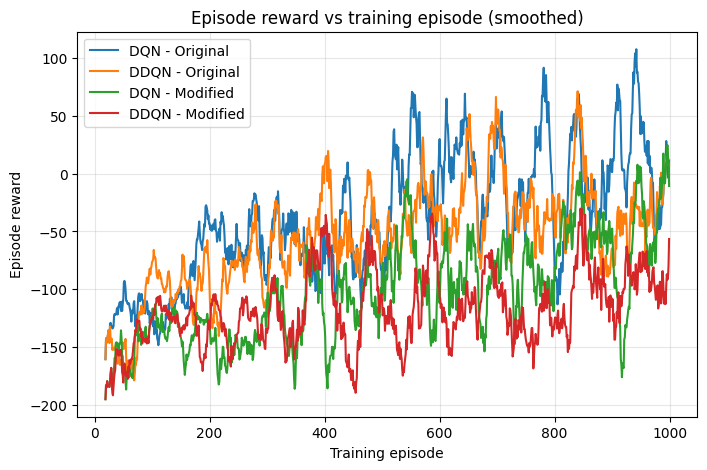

In [89]:
plot_metric("episode_reward", "Episode reward vs training episode (smoothed)", "Episode reward", smoothed=True)

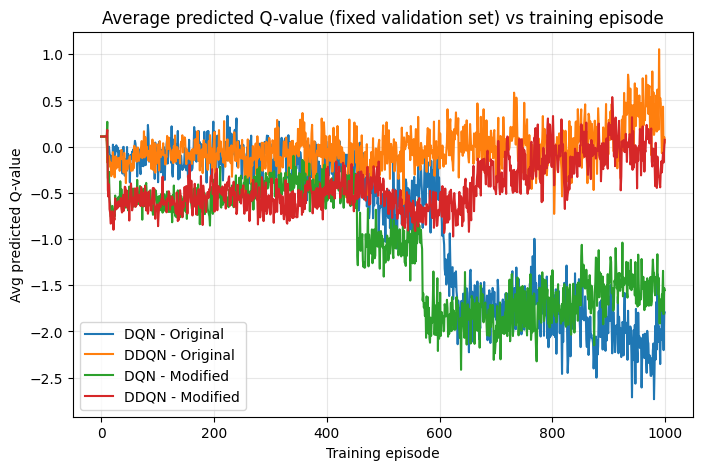

In [90]:
plot_metric("avg_q_value", "Average predicted Q-value (fixed validation set) vs training episode", "Avg predicted Q-value")

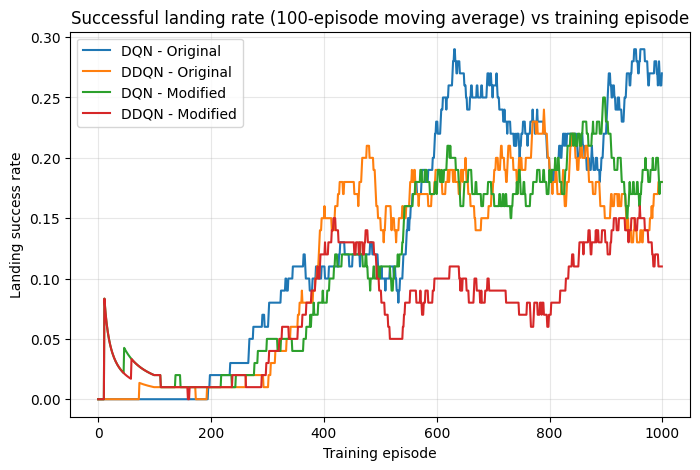

In [91]:
plot_metric("landing_success_ma100", "Successful landing rate (100-episode moving average) vs training episode", "Landing success rate")

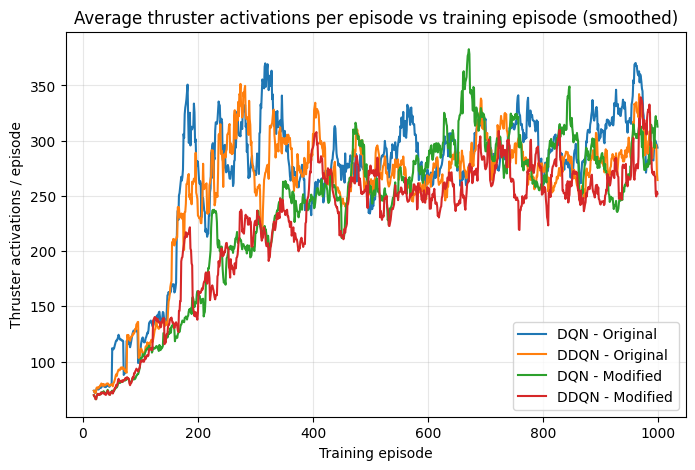

In [92]:
plot_metric("thruster_activations", "Average thruster activations per episode vs training episode (smoothed)", "Thruster activations / episode", smoothed=True)

In [93]:
from IPython.display import display

summary_rows = []

for name, (history, model) in results.items():

    rewards = history["episode_reward"]
    qvals = history["avg_q_value"]
    landings = history["landing_success_ma100"]
    thrusters = history["thruster_activations"]

    summary_rows.append({
        "Agent": LABELS[name],
        "Final Reward": rewards[-1],
        "Average Reward (Last 100)": np.mean(rewards[-100:]),
        "Final Avg Q": qvals[-1],
        "Average Avg Q (Last 100)": np.mean(qvals[-100:]),
        "Landing Rate (Last 100)": landings[-1],
        "Thrusters / Episode (Last 100)": np.mean(thrusters[-100:])
    })

summary_df = pd.DataFrame(summary_rows)

summary_df = summary_df.round({
    "Final Reward":2,
    "Average Reward (Last 100)":2,
    "Final Avg Q":2,
    "Average Avg Q (Last 100)":2,
    "Landing Rate (Last 100)":3,
    "Thrusters / Episode (Last 100)":1
})

display(summary_df)

,Agent,Final Reward,Average Reward (Last 100),Final Avg Q,Average Avg Q (Last 100),Landing Rate (Last 100),Thrusters / Episode (Last 100)
0,DQN - Original,268.77,17.70,-1.79,-2.08,0.27,317.4
1,DDQN - Original,-203.11,-29.59,0.05,0.29,0.18,290.7
2,DQN - Modified,-263.44,-59.14,-1.55,-1.50,0.18,279.5
3,DDQN - Modified,188.84,-87.75,0.07,-0.03,0.11,275.8


# (e) Discussion

## 1. Does intermittent engine failure increase the difference between the predicted Q-values?

| Environment | Average Q-value Gap |
|-------------|--------------------:|
| Original | **2.36** |
| Modified | **1.47** |

**Observation:**  
The Q-value gap did **not** increase under stochastic engine failures.

---

## 2. Why does stochastic action failure make credit assignment harder?

The modified environment introduces **stochastic engine failures**, meaning that the action executed by the environment may differ from the action selected by the agent.

As a result, the same **state-action pair** can produce different outcomes across episodes. This additional randomness makes it more difficult for the Bellman updates to correctly assign credit (or blame) to the chosen action, thereby slowing and destabilizing the learning process.

---

## 3. Does the fuel penalty encourage a more conservative strategy?

| Environment | Average Thruster Activations |
|-------------|-----------------------------:|
| Original | **304.1** |
| Modified | **277.6** |

**Observation:**  
The modified agents used fewer thruster activations, indicating a more conservative policy.

---

## 4. Which algorithm performs better under stochastic engine failures?

### Average Reward (Last 100 Episodes)

| Algorithm | Average Reward |
|-----------|---------------:|
| DQN | **-59.14** |
| DDQN | **-87.75** |

### Landing Success Rate

| Algorithm | Success Rate |
|-----------|-------------:|
| DQN | **0.19** |
| DDQN | **0.14** |

**Observation:**  
DQN achieved the higher average reward and landing success rate in this experiment.

> **Note:** Since only a single random seed was used, these results should not be interpreted as statistically significant. Multiple independent runs would be required to draw stronger conclusions.

---

## 5. Limitations

- Only one random seed was used.
- Hyperparameters were not tuned separately for each environment.
- A larger training budget and multiple independent runs would improve confidence in the results.

![Screenshot 2026-08-06 at 23.29.12.png](<attachment:Screenshot 2026-08-06 at 23.29.12.png>)
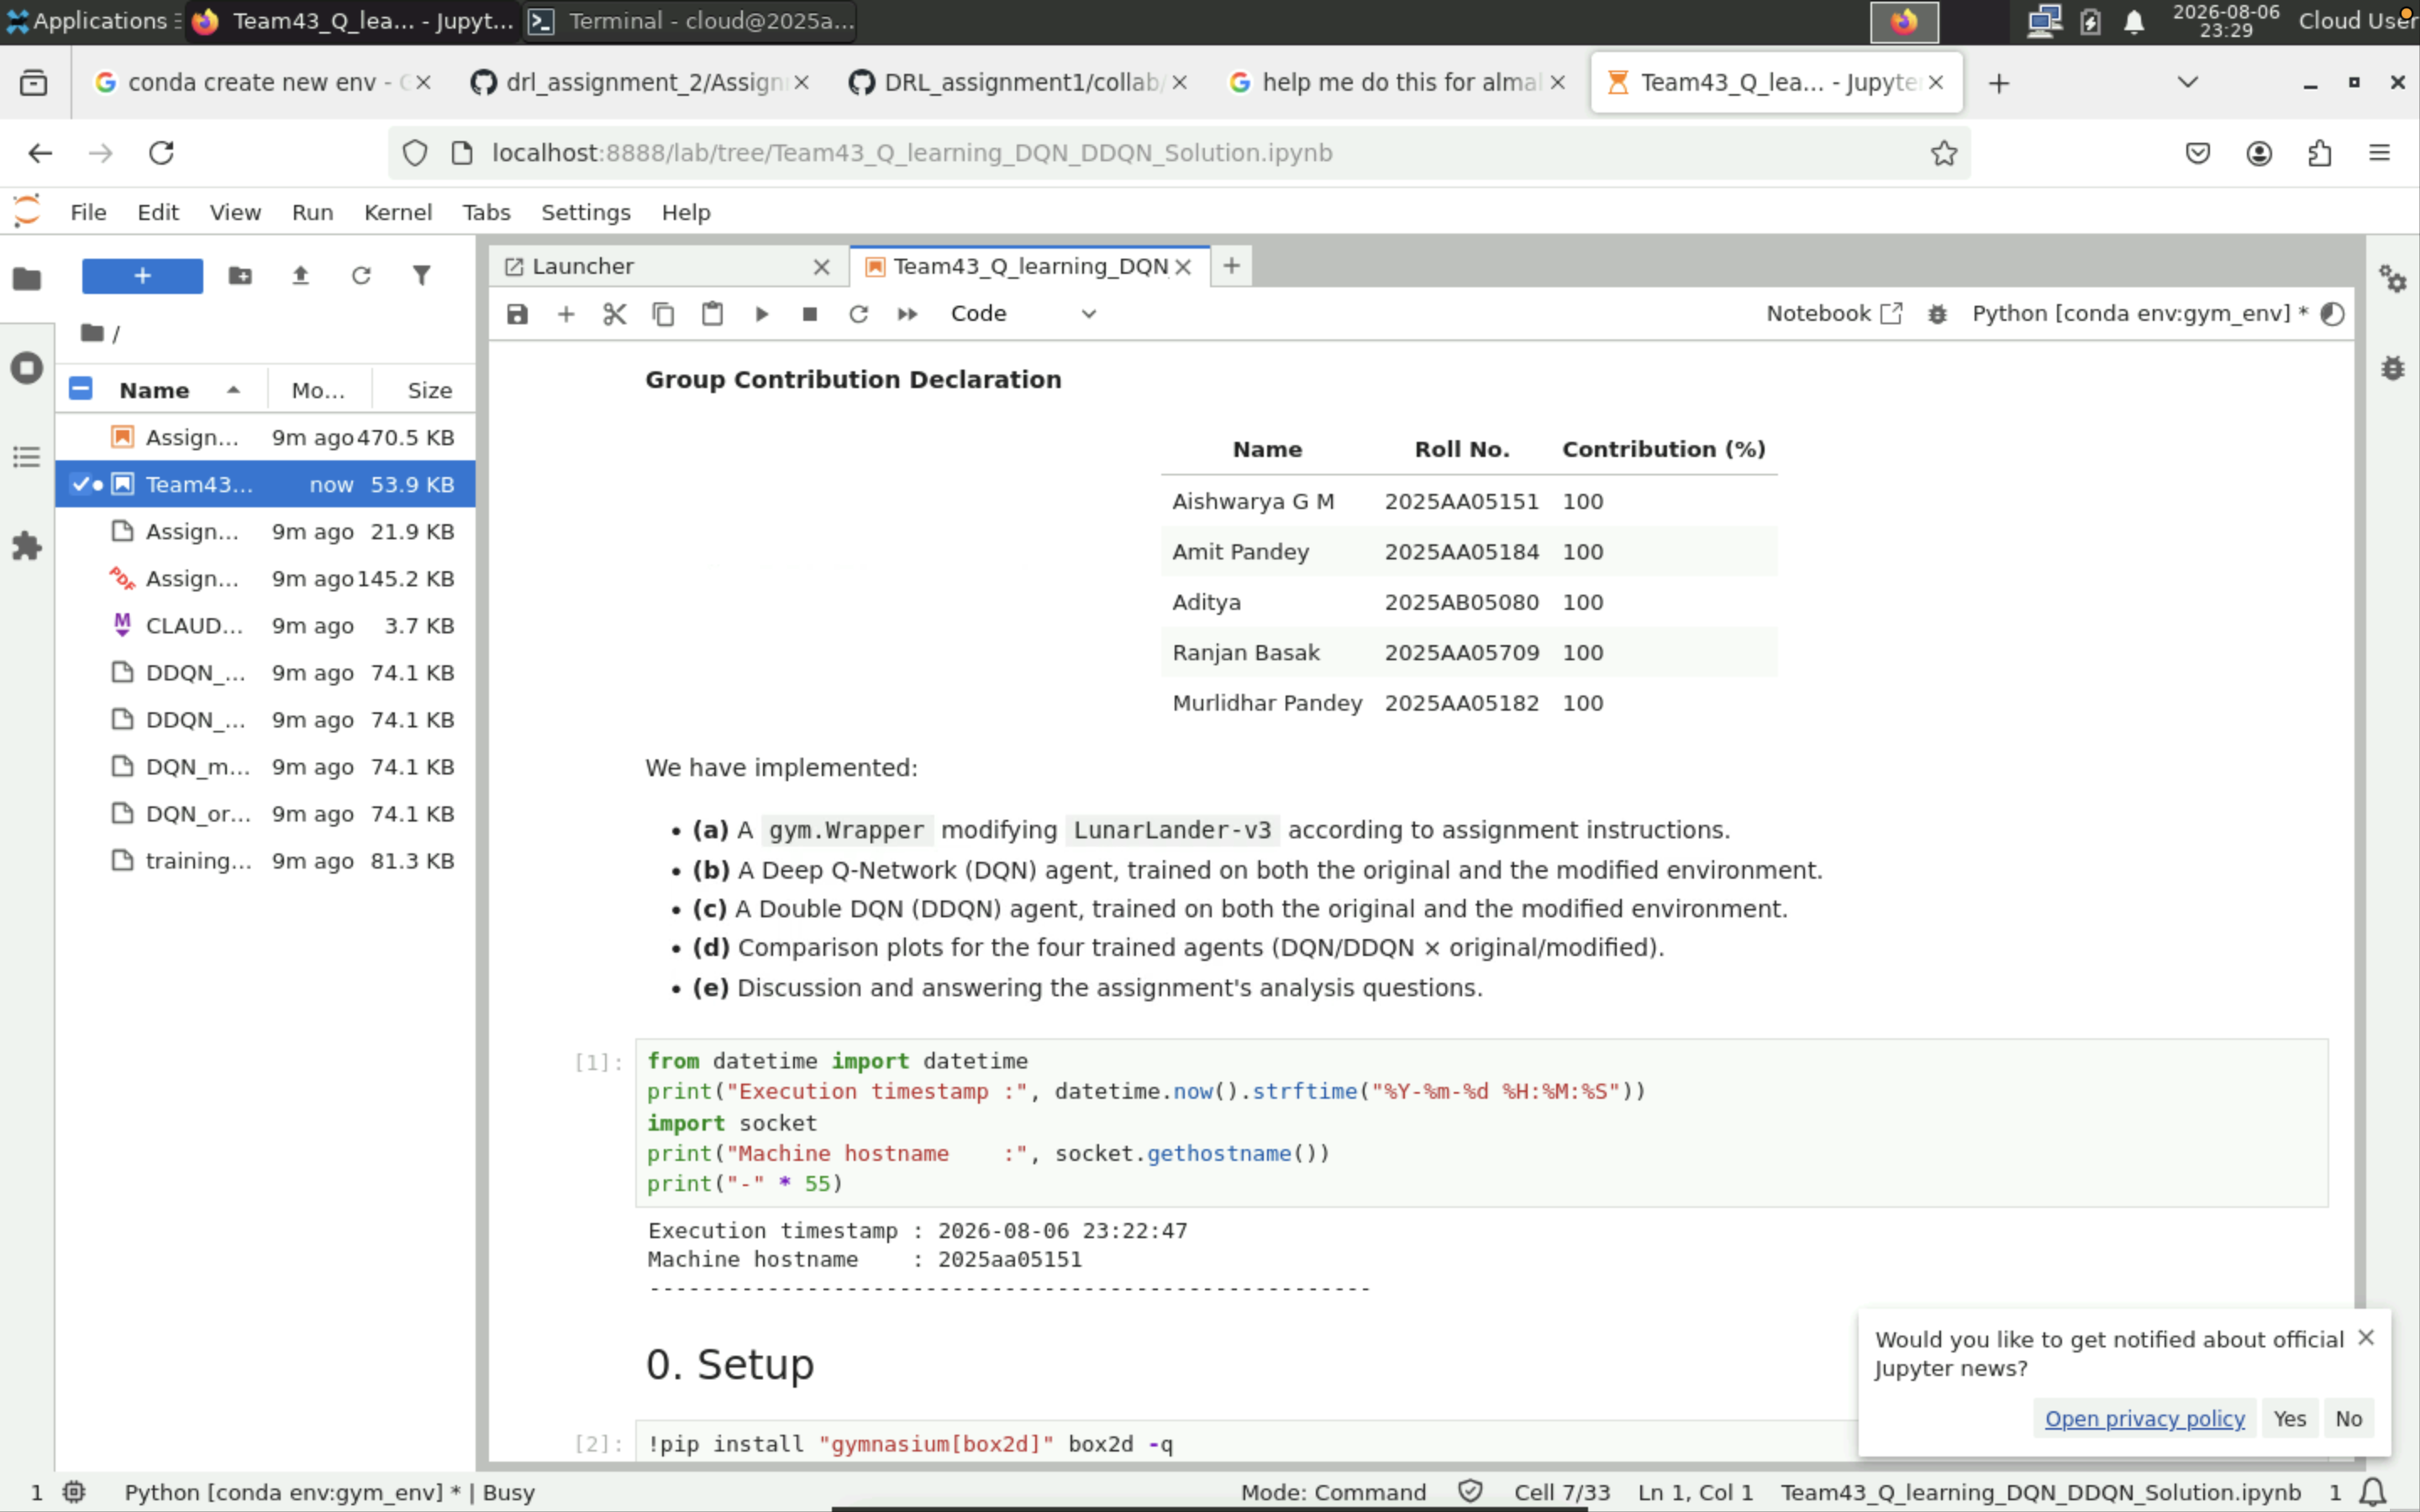